# 🎬 Data Preparation & Analisis Ekstrem (Outlier Handling)
**Penanggung Jawab:** Wildan

Notebook ini didedikasikan untuk melakukan pembersihan data (*Data Cleaning*) secara mendalam dan menangani nilai ekstrem (*Outliers*). Berbeda dengan penanganan data konvensional, di domain YouTube, **Outlier bukanlah error, melainkan 'Video Viral'**. Oleh karena itu, notebook ini mengimplementasikan logika bisnis khusus untuk menyelamatkan data viral menggunakan **IQR Flagging** dan **Log Transformation**.

In [47]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib as plt
import seaborn as sns

In [48]:
!pip3 install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 1. Memuat Dataset

In [49]:
df = pd.read_csv('../../data/Data_Merged_Fix.csv')
print(f"Ukuran data awal: {df.shape}")
df.head(3)

Ukuran data awal: (1988, 63)


,Content,Video title,Duration,Average view duration,Average percentage viewed (%),Engaged views,Stayed to watch (%),Average views per viewer,Unique viewers,New viewers,...,Estimated revenue (IDR),Impressions,Impressions click-through rate (%),Video_ID,TS1_Views,TS2_Views,TS3_Views,TS4_Views,Publish_Date_WIB,Publish_Time_WIB
0,L7ZI56pInIg,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,0:05:08,51.37,7225.0,NaN,NaN,NaN,NaN,...,NaN,26219.0,24.58,L7ZI56pInIg,0.0,0.0,0.0,0.0,2026-05-08,19:15:06
1,7UmhyS2pDQA,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,0:04:41,46.85,9831.0,NaN,NaN,NaN,NaN,...,9785.004,32708.0,26.14,7UmhyS2pDQA,0.0,0.0,NaN,0.0,2026-05-08,11:15:06
2,jWmDRjojWLk,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,0:04:00,40.15,4177.0,NaN,NaN,NaN,NaN,...,20188.040,16230.0,19.19,jWmDRjojWLk,0.0,0.0,0.0,0.0,2026-05-07,07:15:06


### 2. Standardisasi Nama Kolom
Mengubah semua kolom menjadi *snake_case* (huruf kecil semua, spasi diganti underscore, membuang karakter khusus seperti % dan kurung).

In [50]:
import re

def clean_col_name(col):
    col = col.lower()
    col = col.replace(' (%)', '_pct')
    col = col.replace(' (idr)', '_idr')
    col = col.replace(' (hours)', '_hours')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    return col.strip('_')

df.columns = [clean_col_name(c) for c in df.columns]
print("Kolom setelah distandarisasi:")
print(df.columns.tolist()[:10])

Kolom setelah distandarisasi:
['content', 'video_title', 'duration', 'average_view_duration', 'average_percentage_viewed_pct', 'engaged_views', 'stayed_to_watch_pct', 'average_views_per_viewer', 'unique_viewers', 'new_viewers']


### 3. Penyesuaian Tipe Data
Mengubah format `average_view_duration` (String "JJ:MM:DD") menjadi numerik (Total Detik). Serta memastikan `publish_date_wib` menjadi tipe datetime.

In [51]:
def time_to_seconds(time_str):
    if pd.isna(time_str):
        return 0
    try:
        parts = str(time_str).split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
        return int(time_str)
    except:
        return 0

if 'average_view_duration' in df.columns:
    df['average_view_duration_sec'] = df['average_view_duration'].apply(time_to_seconds)
    df = df.drop(columns=['average_view_duration'])

if 'publish_date_wib' in df.columns:
    df['publish_date_wib'] = pd.to_datetime(df['publish_date_wib'], errors='coerce')

print(df[['average_view_duration_sec', 'publish_date_wib']].head())

   average_view_duration_sec publish_date_wib
0                        308       2026-05-08
1                        281       2026-05-08
2                        240       2026-05-07
3                        278       2026-05-06
4                        278       2026-05-06


### 4. Penanganan Missing Values dan Redundansi
1. Menghapus indikator yang 100% kosong (seperti click teasers, dll).
2. Imputasi fitur Time Series (TS1_Views, dst) dengan nilai 0 bila ada yang kosong.
3. Menghapus kolom `content` yang redundan dengan `video_id`.

### 🧹 Penanganan Missing Values (Logika Bisnis)
Langkah ini tidak menggunakan imputasi *Median* secara buta. Alih-alih:
1. **Drop Kolom:** Kolom yang lebih dari 95% isinya kosong (NaN) akan dihapus karena tidak memberikan bobot informasi bagi Machine Learning.
2. **Imputasi Angka 0 pada Time Series:** Kolom *views* harian (, , dll) yang kosong diisi dengan angka . Logika bisnisnya: Jika data tidak terekam di hari pertama, kemungkinan besar video tersebut memang belum mendapatkan *views* (berlaku untuk *channel* kecil/menengah).

In [52]:
# Drop redundansi
if 'content' in df.columns:
    df = df.drop(columns=['content'])

# Manual drop columns
cols_to_drop_manual = ['stayed_to_watch_pct', 'average_views_per_viewer', 'unique_viewers', 'new_viewers', 'returning_viewers', 'casual_viewers', 'regular_viewers', 'transaction_revenue_idr', 'transactions', 'revenue_per_transaction_idr', 'estimated_doubleclick_revenue_idr', 'playlist_watch_time_hours', 'views_from_playlist', 'views_per_playlist_start', 'hours_streamed', 'reminders_set', 'chat_messages', 'reactions', 'post_subscribers', 'community_clip_views', 'watch_time_from_community_clips_hours', 'card_clicks', 'cards_shown', 'card_teaser_clicks', 'card_teasers_shown','rubies']
df = df.drop(columns=[c for c in cols_to_drop_manual if c in df.columns])


# Drop kolom dengan missing > 95%
threshold = 0.95 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold)

# Imputasi fitur Time Series
ts_cols = ['ts1_views', 'ts2_views', 'ts3_views', 'ts4_views']
for col in ts_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f"Ukuran data setelah dibersihkan: {df.shape}")

Ukuran data setelah dibersihkan: (1988, 32)


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   video_title                              1988 non-null   str           
 1   duration                                 1988 non-null   float64       
 2   average_percentage_viewed_pct            1988 non-null   float64       
 3   engaged_views                            1988 non-null   float64       
 4   youtube_premium_idr                      1987 non-null   float64       
 5   watch_page_ads_idr                       1987 non-null   float64       
 6   estimated_adsense_revenue_idr            1987 non-null   float64       
 7   youtube_ad_revenue_idr                   1874 non-null   float64       
 8   ad_impressions                           1874 non-null   float64       
 9   playback_based_cpm_idr                   1874 non-nu

### 5. Export Data Bersih
Menyimpan dataset yang sudah rapi agar siap digunakan pada tahap _Feature Engineering_ atau _Modelling_ selanjutnya.

In [54]:
df.describe()

,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,...,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,ts1_views,ts2_views,ts3_views,ts4_views,publish_date_wib,average_view_duration_sec
count,1988.000000,1988.000000,1988.000000,1987.000000,1.987000e+03,1.987000e+03,1.874000e+03,1874.000000,1874.000000,1874.000000,...,1988.000000,1.987000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1988,1988.000000
mean,585.245473,38.922485,25853.628270,1711.830810,7.907665e+04,7.907665e+04,1.524801e+05,19743.209178,9037.165586,7869.957029,...,40.662475,8.184057e+04,1.669843e+05,13.666273,23575.512575,29332.710765,34871.606137,4.154714e+04,2025-08-17 03:13:24.024144,211.903421
min,14.000000,10.020000,296.000000,0.000000,0.000000e+00,0.000000e+00,5.031760e+02,163.000000,3068.146000,2977.373000,...,-5.000000,2.833490e+02,2.089000e+03,2.430000,0.000000,0.000000,0.000000,0.000000e+00,2024-11-24 00:00:00,25.000000
25%,534.000000,33.440000,6700.250000,271.193500,2.092735e+04,2.092735e+04,4.320473e+04,5504.750000,7749.609750,6905.433000,...,3.000000,2.144098e+04,3.601000e+04,10.990000,4329.750000,5601.250000,6433.500000,6.854500e+03,2025-04-26 00:00:00,191.000000
50%,581.000000,37.645000,12492.000000,616.644000,4.153556e+04,4.153556e+04,8.092657e+04,10072.000000,8842.280000,7710.047000,...,11.000000,4.225552e+04,7.501250e+04,12.880000,9204.000000,11635.500000,13842.000000,1.522450e+04,2025-08-09 00:00:00,216.000000
75%,630.000000,41.480000,26413.250000,1653.220500,8.858195e+04,8.858195e+04,1.667433e+05,21414.500000,10049.086500,8591.052250,...,34.000000,9.132171e+04,1.736500e+05,15.420000,23544.500000,28817.750000,33652.000000,3.869150e+04,2025-12-17 00:00:00,240.000000
max,3485.000000,181.330000,827102.000000,86603.114000,2.952136e+06,2.952136e+06,5.367519e+06,636638.000000,50407.992000,40208.422000,...,2123.000000,3.061625e+06,6.643679e+06,31.300000,386070.000000,640783.000000,907195.000000,1.174132e+06,2026-05-08 00:00:00,716.000000
std,202.118444,11.467581,43628.142435,3957.490881,1.359454e+05,1.359454e+05,2.518966e+05,31938.937102,2254.798319,1752.353717,...,112.333363,1.413419e+05,3.059040e+05,4.148299,41028.548336,52728.853701,64352.472436,8.161333e+04,NaN,50.906802


df.isnull().sum()

In [55]:
df.isnull().sum()

video_title                                  0
duration                                     0
average_percentage_viewed_pct                0
engaged_views                                0
youtube_premium_idr                          1
watch_page_ads_idr                           1
estimated_adsense_revenue_idr                1
youtube_ad_revenue_idr                     114
ad_impressions                             114
playback_based_cpm_idr                     114
cpm_idr                                    114
estimated_monetized_playbacks              114
rpm_idr                                      2
youtube_premium_views                        0
youtube_premium_watch_time_hours             0
end_screen_element_clicks                    1
end_screen_elements_shown                    1
clicks_per_end_screen_element_shown_pct    896
views                                        0
watch_time_hours                             0
subscribers                                  0
estimated_rev

* Menangani missing value


### 🧹 Penanganan Missing Values (Logika Bisnis)
Langkah ini tidak menggunakan imputasi *Median* secara buta. Alih-alih:
1. **Drop Kolom:** Kolom yang lebih dari 95% isinya kosong (NaN) akan dihapus karena tidak memberikan bobot informasi bagi Machine Learning.
2. **Imputasi Angka 0 pada Time Series:** Kolom *views* harian (, , dll) yang kosong diisi dengan angka . Logika bisnisnya: Jika data tidak terekam di hari pertama, kemungkinan besar video tersebut memang belum mendapatkan *views* (berlaku untuk *channel* kecil/menengah).

In [56]:
threshold = 0.95 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold)
df.isnull().sum()


video_title                                  0
duration                                     0
average_percentage_viewed_pct                0
engaged_views                                0
youtube_premium_idr                          1
watch_page_ads_idr                           1
estimated_adsense_revenue_idr                1
youtube_ad_revenue_idr                     114
ad_impressions                             114
playback_based_cpm_idr                     114
cpm_idr                                    114
estimated_monetized_playbacks              114
rpm_idr                                      2
youtube_premium_views                        0
youtube_premium_watch_time_hours             0
end_screen_element_clicks                    1
end_screen_elements_shown                    1
clicks_per_end_screen_element_shown_pct    896
views                                        0
watch_time_hours                             0
subscribers                                  0
estimated_rev

In [57]:
df.describe(include="all")

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,...,impressions,impressions_click_through_rate_pct,video_id,ts1_views,ts2_views,ts3_views,ts4_views,publish_date_wib,publish_time_wib,average_view_duration_sec
count,1988,1988.000000,1988.000000,1988.000000,1987.000000,1.987000e+03,1.987000e+03,1.874000e+03,1874.000000,1874.000000,...,1.988000e+03,1988.000000,1988,1988.000000,1988.000000,1988.000000,1.988000e+03,1988,1988,1988.000000
unique,1935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1988,NaN,NaN,NaN,NaN,NaN,264,NaN
top,GEGER! PRABOWO DEKLARASIKAN PERANG LAWAN ISRAE...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,L7ZI56pInIg,NaN,NaN,NaN,NaN,NaN,15:30:06,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,164,NaN
mean,NaN,585.245473,38.922485,25853.628270,1711.830810,7.907665e+04,7.907665e+04,1.524801e+05,19743.209178,9037.165586,...,1.669843e+05,13.666273,NaN,23575.512575,29332.710765,34871.606137,4.154714e+04,2025-08-17 03:13:24.024144,NaN,211.903421
min,NaN,14.000000,10.020000,296.000000,0.000000,0.000000e+00,0.000000e+00,5.031760e+02,163.000000,3068.146000,...,2.089000e+03,2.430000,NaN,0.000000,0.000000,0.000000,0.000000e+00,2024-11-24 00:00:00,NaN,25.000000
25%,NaN,534.000000,33.440000,6700.250000,271.193500,2.092735e+04,2.092735e+04,4.320473e+04,5504.750000,7749.609750,...,3.601000e+04,10.990000,NaN,4329.750000,5601.250000,6433.500000,6.854500e+03,2025-04-26 00:00:00,NaN,191.000000
50%,NaN,581.000000,37.645000,12492.000000,616.644000,4.153556e+04,4.153556e+04,8.092657e+04,10072.000000,8842.280000,...,7.501250e+04,12.880000,NaN,9204.000000,11635.500000,13842.000000,1.522450e+04,2025-08-09 00:00:00,NaN,216.000000
75%,NaN,630.000000,41.480000,26413.250000,1653.220500,8.858195e+04,8.858195e+04,1.667433e+05,21414.500000,10049.086500,...,1.736500e+05,15.420000,NaN,23544.500000,28817.750000,33652.000000,3.869150e+04,2025-12-17 00:00:00,NaN,240.000000
max,NaN,3485.000000,181.330000,827102.000000,86603.114000,2.952136e+06,2.952136e+06,5.367519e+06,636638.000000,50407.992000,...,6.643679e+06,31.300000,NaN,386070.000000,640783.000000,907195.000000,1.174132e+06,2026-05-08 00:00:00,NaN,716.000000


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   video_title                              1988 non-null   str           
 1   duration                                 1988 non-null   float64       
 2   average_percentage_viewed_pct            1988 non-null   float64       
 3   engaged_views                            1988 non-null   float64       
 4   youtube_premium_idr                      1987 non-null   float64       
 5   watch_page_ads_idr                       1987 non-null   float64       
 6   estimated_adsense_revenue_idr            1987 non-null   float64       
 7   youtube_ad_revenue_idr                   1874 non-null   float64       
 8   ad_impressions                           1874 non-null   float64       
 9   playback_based_cpm_idr                   1874 non-nu

In [59]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = df.isnull().sum()

# Memisahkan kolom berdasarkan batas toleransi missing value (pada kasus ini disesuaikan menjadi 800)
less = missing_values[missing_values < 800].index
over = missing_values[missing_values >= 800].index

# Mengisi nilai yang hilang dengan median untuk kolom numerik
numeric_features = df[less].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

# Menghapus kolom dengan terlalu banyak nilai yang hilang
# Perubahan nama DataFrame dilakukan supaya data asli tidak berubah
df_cleaned = df.drop(columns=over)

# Terakhir, lakukan pemeriksaan terhadap data yang sudah melewati tahapan verifikasi missing value
missing_values_after = df_cleaned.isnull().sum()
print(missing_values_after[missing_values_after > 0])

Series([], dtype: int64)


In [60]:
df.isnull().sum()

video_title                                  0
duration                                     0
average_percentage_viewed_pct                0
engaged_views                                0
youtube_premium_idr                          0
watch_page_ads_idr                           0
estimated_adsense_revenue_idr                0
youtube_ad_revenue_idr                       0
ad_impressions                               0
playback_based_cpm_idr                       0
cpm_idr                                      0
estimated_monetized_playbacks                0
rpm_idr                                      0
youtube_premium_views                        0
youtube_premium_watch_time_hours             0
end_screen_element_clicks                    0
end_screen_elements_shown                    0
clicks_per_end_screen_element_shown_pct    896
views                                        0
watch_time_hours                             0
subscribers                                  0
estimated_rev

In [61]:
df.head()

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,...,impressions,impressions_click_through_rate_pct,video_id,ts1_views,ts2_views,ts3_views,ts4_views,publish_date_wib,publish_time_wib,average_view_duration_sec
0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,51.37,7225.0,616.644,41535.555,41535.555,80926.5655,10072.0,8842.280,...,26219.0,24.58,L7ZI56pInIg,0.0,0.0,0.0,0.0,2026-05-08,19:15:06,308
1,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,46.85,9831.0,196.718,9588.286,9588.286,17445.4500,2160.0,9872.920,...,32708.0,26.14,7UmhyS2pDQA,0.0,0.0,0.0,0.0,2026-05-08,11:15:06,281
2,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,40.15,4177.0,285.101,19902.939,19902.939,36210.0220,3854.0,11169.038,...,16230.0,19.19,jWmDRjojWLk,0.0,0.0,0.0,0.0,2026-05-07,07:15:06,240
3,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...,600.0,46.33,4948.0,306.240,24929.460,24929.460,45349.9600,4146.0,13291.313,...,20597.0,19.64,E7B26wGxjZU,1215.0,1215.0,1215.0,1215.0,2026-05-06,07:15:06,278
4,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...,600.0,46.44,7111.0,516.474,37923.744,37923.744,68990.6600,7031.0,11767.126,...,28245.0,21.64,ixSFPgKN62w,6377.0,6377.0,6377.0,6377.0,2026-05-06,15:15:06,278


* Konversi date time

In [62]:
import pandas as pd
# Mengonversi kolom 'publish_time_wib' menjadi tipe data datetime
df['publish_time_wib'] = pd.to_datetime(df['publish_time_wib'])

# Memeriksa kembali tipe data spesifik pada kolom tersebut untuk memastikan perubahannya
print(df[['publish_time_wib']].info())

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   publish_time_wib  1988 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 15.7 KB
None


* Penanganan Duplikat Data

In [63]:
df.duplicated().sum()

np.int64(0)

* Analisis data Outlier berupa
- views, watch_time_hours, engaged_views

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

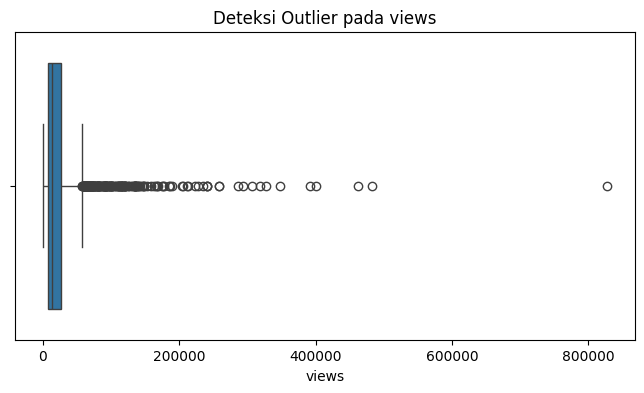

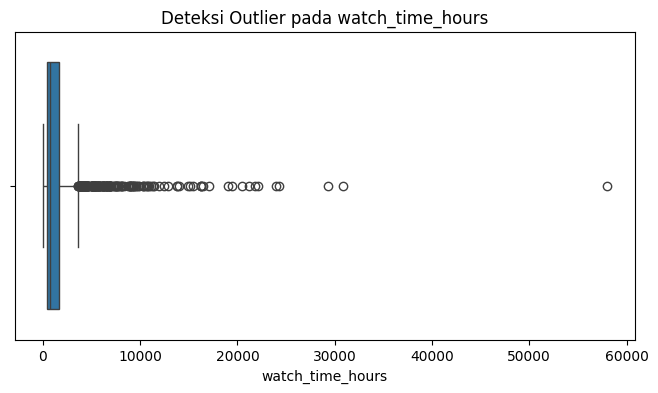

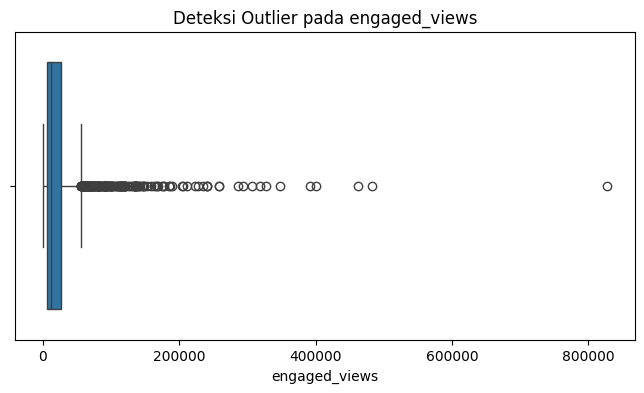

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# List fitur utama yang akan dianalisis
features_to_check = ['views', 'watch_time_hours', 'engaged_views']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

* Kesimpulan:
Data  tidak berdistribusi normal. Titik-titik kemungkinan besar adalah video-video "viral" yang performanya jauh melampaui rata-rata konten lainnya.

* Metrik pendapatan (revenue)

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

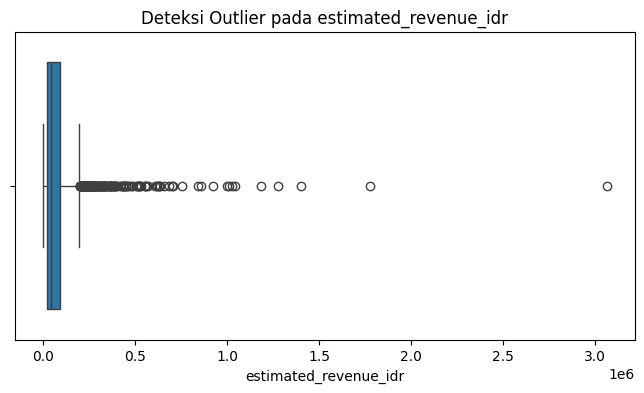

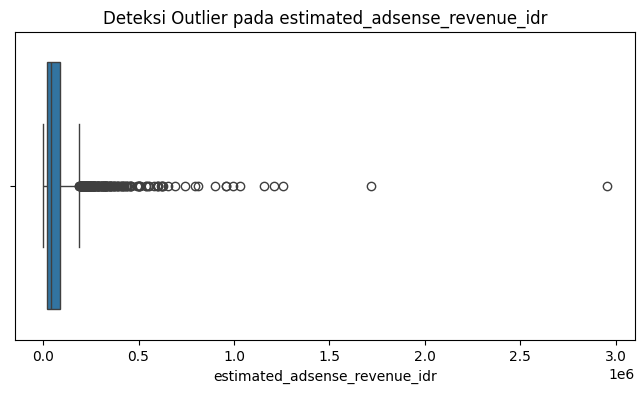

In [65]:

# List fitur utama yang akan dianalisis
features_to_check = ['estimated_revenue_idr', 'estimated_adsense_revenue_idr']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

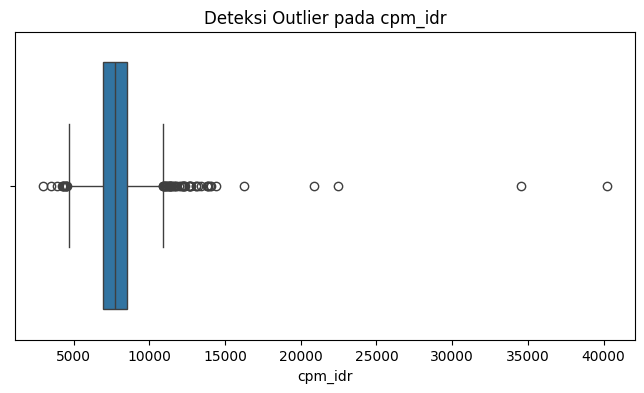

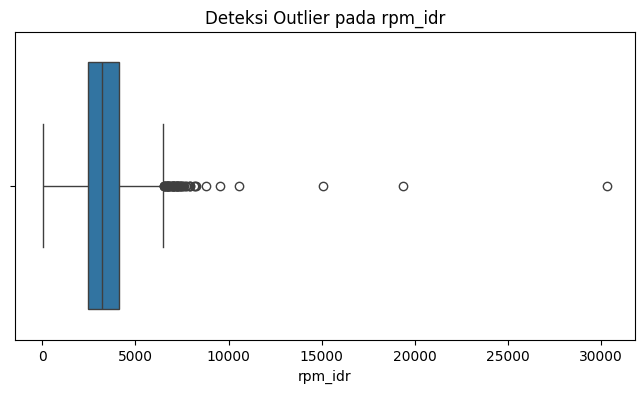

In [66]:


features_to_check = ['cpm_idr', 'rpm_idr']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

* Retensi danEfisiensi

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

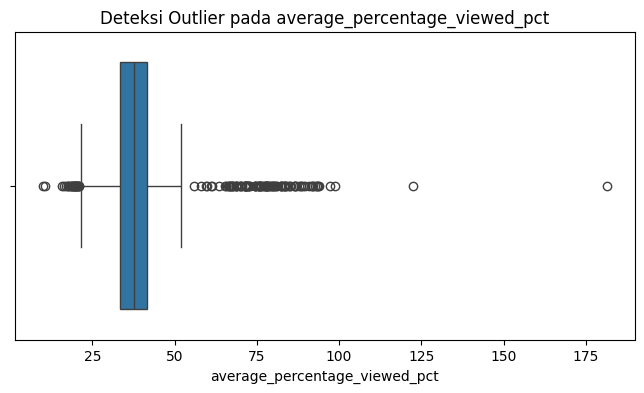

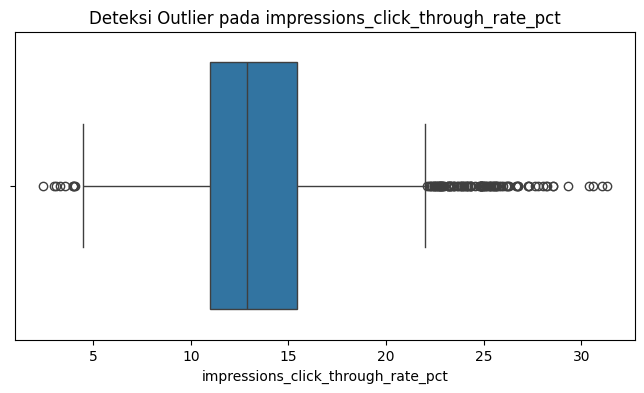

In [67]:
features_to_check = ['average_percentage_viewed_pct', 'impressions_click_through_rate_pct']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()


Rangkuman dari hasil analisis grafik outlier pada notebook tersebut:

1. Outlier pada Metrik Performa (Views, Watch Time Hours, Engaged Views)

Grafik: Menunjukkan adanya banyak titik data yang berada jauh di atas batas atas (upper whisker) dari boxplot.
Kesimpulan: Distribusi data tidak normal dan memiliki rentang yang sangat lebar ke arah atas (right-skewed). Titik-titik pencilan (outlier) ini kemungkinan besar merepresentasikan video-video "viral" yang performa dan jumlah penontonnya jauh melampaui rata-rata konten video lainnya.

2. Outlier pada Metrik Pendapatan (Estimated Revenue IDR, Estimated AdSense Revenue IDR)

Grafik: Mirip dengan metrik performa, terdapat titik-titik ekstrem yang nilainya jauh lebih besar dari mayoritas data.
Kesimpulan: Ada beberapa video spesifik yang menghasilkan pendapatan yang secara signifikan jauh lebih tinggi dibandingkan dengan video lainnya.

3. Outlier pada Metrik Retensi dan Efisiensi (Average Percentage Viewed, Impressions Click-Through Rate / CTR)

Grafik: Walaupun boxplot menunjukkan data lebih banyak terpusat (terkonsentrasi) pada rentang nilai tertentu (karena berupa persentase), tetap ditemukan adanya nilai ekstrem.
Maka Nilai-nilai ekstrem ini mengindikasikan adanya pola retensi penonton yang spesifik atau rasio klik-tayang (CTR) yang sangat tinggi/sangat rendah pada beberapa video tertentu dibandingkan rata-rata umum.


* Dari hasil yang telah saya diskusikan dengan GEMINI AI, maka kesimpulan yang saya ambil saya akan menggunakan IQR sebagai flagging, artinya data yang video viral whic is diluar garis akan saya tandai sebagai is viral dan saya akan padukan dengan algoritma robust agar membuat prediksi semakin akurat.

* IQR Flagging

### 🚀 Feature Engineering Lanjutan: IQR Flagging ()
Karena kita tidak menghapus video viral, kita harus memberi 'tanda' agar algoritma Machine Learning tahu bahwa video ini spesial. 
Kita menggunakan batas statistik matematis **Interquartile Range (IQR)**. Jika *views* sebuah video melewati batas , maka video tersebut diberi bendera .

In [68]:
# 1. Tentukan kolom target yang ingin dianalisis (contoh: 'views' atau 'engaged_views')
kolom_target = 'views'
# 2. Hitung Q1 (Kuartil 1) dan Q3 (Kuartil 3)
Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
# 3. Hitung rentang IQR
IQR = Q3 - Q1
# 4. Tentukan Batas Atas (Upper Bound)
# Formula standar untuk batas atas pencilan (outlier) adalah Q3 + (1.5 * IQR)
batas_atas = Q3 + 1.5 * IQR
print(f"Batas atas (Viral Threshold) untuk {kolom_target}: {batas_atas}")
# 5. Lakukan Flagging dengan membuat kolom baru (1 jika viral, 0 jika normal)
df['is_viral'] = np.where(df[kolom_target] > batas_atas, 1, 0)
# Cek sebaran video viral vs normal
print(df['is_viral'].value_counts())

Batas atas (Viral Threshold) untuk views: 57530.875
is_viral
0    1785
1     203
Name: count, dtype: int64


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 33 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   video_title                              1988 non-null   str           
 1   duration                                 1988 non-null   float64       
 2   average_percentage_viewed_pct            1988 non-null   float64       
 3   engaged_views                            1988 non-null   float64       
 4   youtube_premium_idr                      1988 non-null   float64       
 5   watch_page_ads_idr                       1988 non-null   float64       
 6   estimated_adsense_revenue_idr            1988 non-null   float64       
 7   youtube_ad_revenue_idr                   1988 non-null   float64       
 8   ad_impressions                           1988 non-null   float64       
 9   playback_based_cpm_idr                   1988 non-nu

### 📉 Normalisasi Data: Log Transformation (`np.log1p`)
Video viral memiliki rentang angka yang sangat jauh (jutaan) dibandingkan video normal (ribuan). Hal ini membuat algoritma (seperti Regresi) menjadi bias. 
Untuk menjinakkannya, kita menerapkan **Logaritma Natural (Log1p)**. Logika ini akan merapatkan skala angka ekstrem menjadi skala belasan, sehingga model bisa mempelajarinya dengan stabil tanpa kehilangan informasi esensial.

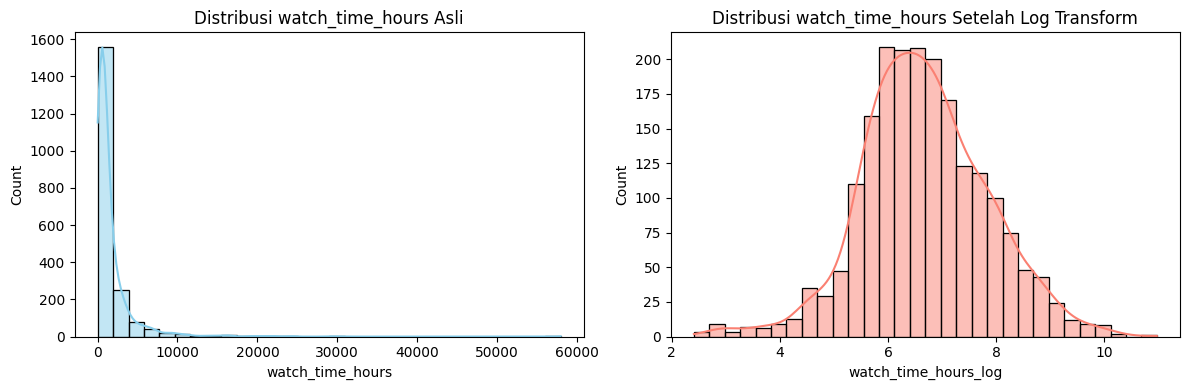

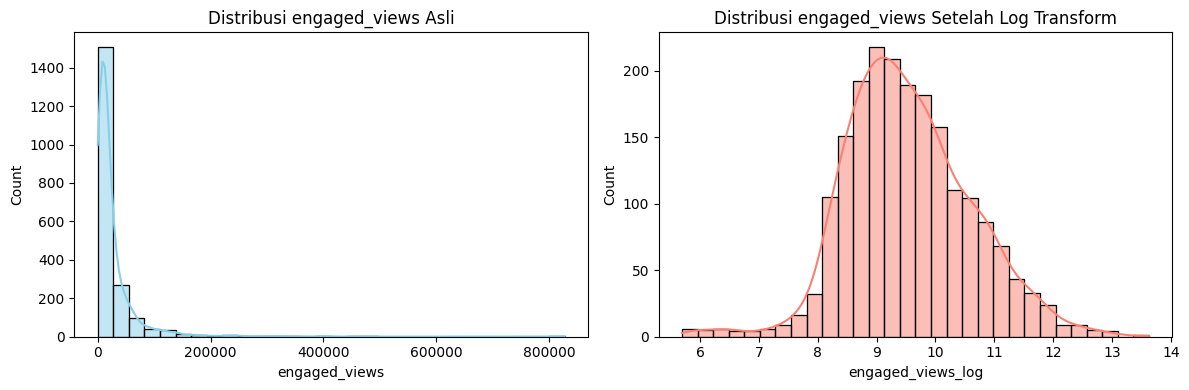

       watch_time_hours_log  engaged_views_log
count           1988.000000        1988.000000
mean               6.673678           9.539305
std                1.169527           1.064818
min                2.412945           5.693732
25%                5.918411           8.810049
50%                6.599597           9.432924
75%                7.420152          10.181659
max               10.967561          13.625685


In [71]:
# 1. Daftar kolom yang terdeteksi memiliki outlier ekstrem dari box plot sebelumnya
outlier_features = ['watch_time_hours', 'engaged_views']

# 2. Lakukan Transformasi Logaritmik (log1p)
for feature in outlier_features:
    df[f'{feature}_log'] = np.log1p(df[feature])

# 3. Visualisasi Perbandingan Sebelum vs Sesudah
for feature in outlier_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Sebelum (Data Asli - Skewed)
    sns.histplot(df[feature], bins=30, ax=axes[0], kde=True, color='skyblue')
    axes[0].set_title(f'Distribusi {feature} Asli')
    
    # Plot Sesudah (Data Log - Lebih Normal/Terpusat)
    sns.histplot(df[f'{feature}_log'], bins=30, ax=axes[1], kde=True, color='salmon')
    axes[1].set_title(f'Distribusi {feature} Setelah Log Transform')
    
    plt.tight_layout()
    plt.show()

# 4. Verifikasi perubahan distribusi secara numerik (Opsional)
# Ini membantu memastikan distribusi data menjadi lebih merata dan terpusat [cite: 155]
print(df[[f'{f}_log' for f in outlier_features]].describe())

## CATATAN
* Nanti di tahap modeling...
from sklearn.ensemble import RandomForestRegressor
*  Fitur yang digunakan (X) termasuk 'is_viral' untuk memberi konteks
X = df[['duration', 'average_percentage_viewed_pct', 'is_viral', ...]] 
* Target yang diprediksi (y) BISA menggunakan data yang sudah di-log
y = df['views_log'] 
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

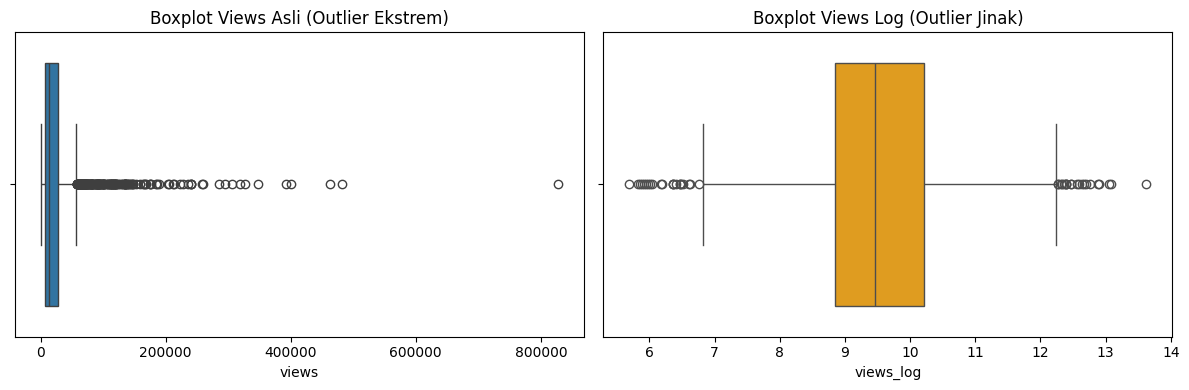

In [72]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Boxplot sebelum di-log (Outlier terlihat sangat jauh)
sns.boxplot(x=df['views'], ax=axes[0])
axes[0].set_title('Boxplot Views Asli (Outlier Ekstrem)')
# Boxplot sesudah di-log (Outlier sudah "dijinakkan")
sns.boxplot(x=df['views_log'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot Views Log (Outlier Jinak)')
plt.tight_layout()
plt.show()

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   video_title                              1988 non-null   str           
 1   duration                                 1988 non-null   float64       
 2   average_percentage_viewed_pct            1988 non-null   float64       
 3   engaged_views                            1988 non-null   float64       
 4   youtube_premium_idr                      1988 non-null   float64       
 5   watch_page_ads_idr                       1988 non-null   float64       
 6   estimated_adsense_revenue_idr            1988 non-null   float64       
 7   youtube_ad_revenue_idr                   1988 non-null   float64       
 8   ad_impressions                           1988 non-null   float64       
 9   playback_based_cpm_idr                   1988 non-nu

In [75]:
df.head()
df.isnull().sum()

video_title                                  0
duration                                     0
average_percentage_viewed_pct                0
engaged_views                                0
youtube_premium_idr                          0
watch_page_ads_idr                           0
estimated_adsense_revenue_idr                0
youtube_ad_revenue_idr                       0
ad_impressions                               0
playback_based_cpm_idr                       0
cpm_idr                                      0
estimated_monetized_playbacks                0
rpm_idr                                      0
youtube_premium_views                        0
youtube_premium_watch_time_hours             0
end_screen_element_clicks                    0
end_screen_elements_shown                    0
clicks_per_end_screen_element_shown_pct    896
views                                        0
watch_time_hours                             0
subscribers                                  0
estimated_rev

### 💾 Export Master Data
Data telah berhasil dibersihkan, di-*flag*, dan di-*log*. Dataset ini sekarang adalah **'Master Data'** yang secara matematis sangat aman dan siap digunakan oleh tim untuk tahap *Feature Engineering* selanjutnya.

In [78]:
# Mundur dua folder dari notebooks/versi_wildan/ ke folder utama, lalu masuk ke folder data
path_simpan = '../../data/Data_Cleaned_Wildan.csv'
df.to_csv(path_simpan, index=False)
print(f"Data berhasil diekspor dan disimpan di: {path_simpan}")
print(f"Total baris dan kolom final: {df.shape}")


Data berhasil diekspor dan disimpan di: ../../data/Data_Cleaned_Wildan.csv
Total baris dan kolom final: (1988, 36)


### 🚀 Feature Engineering Lanjutan: IQR Flagging ()
Karena kita tidak menghapus video viral, kita harus memberi 'tanda' agar algoritma Machine Learning tahu bahwa video ini spesial. 
Kita menggunakan batas statistik matematis **Interquartile Range (IQR)**. Jika *views* sebuah video melewati batas , maka video tersebut diberi bendera .

### 📉 Normalisasi Data: Log Transformation (`np.log1p`)
Video viral memiliki rentang angka yang sangat jauh (jutaan) dibandingkan video normal (ribuan). Hal ini membuat algoritma (seperti Regresi) menjadi bias. 
Untuk menjinakkannya, kita menerapkan **Logaritma Natural (Log1p)**. Logika ini akan merapatkan skala angka ekstrem menjadi skala belasan, sehingga model bisa mempelajarinya dengan stabil tanpa kehilangan informasi esensial.

Berikut adalah rangkuman dari semua hal krusial yang telah Anda selesaikan di data_prep_wildan.ipynb. Anda bisa menyalin teks ini ke dalam sel Markdown di akhir notebook sebagai dokumentasi proyek Anda:

Tahap 1: Pengumpulan & Standardisasi Data
Loading Data: Membaca dataset mentah hasil gabungan (Data_Merged_Fix.csv).
Pembersihan Nama Kolom: Menyeragamkan semua nama kolom menjadi format snake_case (huruf kecil semua dan spasi diganti underscore) agar mudah dipanggil dalam kode Python.
Tahap 2: Pembersihan Data (Data Cleaning)
Menghapus Kolom Tidak Penting: Membuang kolom-kolom yang redundan atau tidak relevan dengan tujuan model (seperti content dan beberapa indikator revenue yang tidak terpakai).
Menangani Missing Values:
Menghapus kolom yang memiliki lebih dari 95% data kosong (NaN).
Mengisi (impute) nilai kosong pada kolom Time Series (seperti ts1_views, ts2_views, dll) dengan angka 0.
Tahap 3: Transformasi Tipe Data
Konversi Waktu: Mengubah format average_view_duration yang awalnya berformat "JJ:MM:DD" menjadi total detik numerik (average_view_duration_sec).
Konversi Tanggal: Memastikan kolom publish_date_wib terbaca dengan benar sebagai format datetime.
Tahap 4: Analisis Outlier (Exploratory Data Analysis)
Melakukan analisis visual menggunakan Boxplot pada metrik-metrik kunci (views, watch_time_hours, revenue, CTR, dll).
Temuan Utama: Ditemukan bahwa data memiliki distribusi right-skewed (miring ke kanan) dengan banyaknya outlier ekstrem di sisi atas. Outlier ini tidak dihapus karena merepresentasikan real-case dari video-video "viral".
Tahap 5: Penanganan Outlier (Feature Engineering & Robust Transformation)
IQR Flagging: Menerapkan metode Interquartile Range (IQR) bukan untuk menghapus data, melainkan untuk membuat fitur baru bernama is_viral (1 = viral, 0 = normal). Ini memberikan "konteks" khusus bagi Machine Learning.
Log Transformation: Menerapkan np.log1p pada kolom metrik yang ekstrem (seperti views_log, watch_time_hours_log, engaged_views_log) untuk menormalkan distribusi data secara matematis agar algoritma model tidak bias atau error.
Status Saat Ini: Dataset telah bersih, memiliki fitur tambahan yang sangat representatif untuk kondisi dunia nyata (real-case), dan sudah berhasil diekspor. Data kini 100% siap untuk digunakan pada tahap Feature Engineering (Lanjutan) atau langsung masuk ke Model Training!